# 19 — 3D PDAC Classification: Final Training

This notebook trains the final 3D PDAC classification baseline on the processed PANORAMA dataset.

## Research purpose

The objective is to train a binary classifier that distinguishes:

- PDAC
- non-PDAC control cases

using the complete preprocessed 3D CT volume `(128, 160, 192)`.

The model is a 3D ResNet-18 initialized with publicly available Kinetics-400 pretrained weights. Because the pretrained model expects three-channel video input while the CT volumes contain one channel, the first convolution is adapted from 3 input channels to 1 input channel by averaging the pretrained RGB filters.

The classification head is replaced with a single output logit for binary PDAC classification.

## Important methodological notes

- The input is a full pancreas-centered 3D CT volume.
- Tumor masks are **not** used as model inputs or to determine the crop.
- The tumor annotation is reserved for the later Grad-CAM evaluation.
- The training split is used to fit model parameters.
- The validation split is used for model selection and learning-rate scheduling.
- If an independent test split exists in `split_assignment.csv`, it is kept completely untouched until final evaluation.
- The best validation checkpoint, rather than the final training epoch, is retained for downstream evaluation.

The earlier timing pilot established that full-volume 3D training fits within the available Kaggle GPU budget on a Tesla T4 (~6.8 GPU-hours for 40 epochs, well under one 12-hour session).

**Note on resuming:** checkpoint resume logic below only helps if this session is interrupted and cells are re-run *without* restarting the kernel. A fresh "Save & Run All" commit starts with an empty `/kaggle/working/`, so resuming across separate commits requires manually attaching the previous run's output as an input dataset first.

In [1]:
# ============================================================
# CELL 2 — IMPORTS, CONFIGURATION, AND REPRODUCIBILITY
# ============================================================

import os
import random
import time
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.models.video import r3d_18, R3D_18_Weights


# ------------------------------------------------------------
# Reproducibility
# ------------------------------------------------------------

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

# ------------------------------------------------------------
# Kaggle paths
# ------------------------------------------------------------

PROCESSED_DIR = Path(
    "/kaggle/input/datasets/shahriarahmed66/panorama-processed-dataset"
)

SPLIT_PATH = PROCESSED_DIR / "split_assignment.csv"
METADATA_PATH = PROCESSED_DIR / "metadata.csv"

# NOTE: renamed from "checkpoints" to "checkpoints_run2" deliberately.
# Run 1's checkpoints already exist at /kaggle/working/checkpoints/ in this
# session. If we reused that directory, Cell 13's resume logic would find
# run 1's latest_checkpoint.pt (epoch 11, old hyperparameters) and silently
# resume from it -- invalidating this entire tuned run. A fresh directory
# guarantees this run starts clean regardless of session state.
CHECKPOINT_DIR = Path("/kaggle/working/checkpoints_run2")
RESULTS_DIR = Path("/kaggle/working/results_run2")

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# Training configuration
# ------------------------------------------------------------

# Doubled from 2 -> 4. Pilot showed 4.27GB peak usage out of 15.6GB
# available at batch_size=2; batch_size=4 lands around ~8.5GB, comfortable
# margin. Larger batches reduce the odds of single-class batches given the
# ~30/70 class imbalance, and are further balanced by the sampler below.
BATCH_SIZE = 4
NUM_WORKERS = 2

# Lowered from 1e-4 -> 5e-5. Run 1 showed sharp val_loss spikes in early
# epochs (epoch 2: 1.31, epoch 7: 1.19) before the scheduler ever reduced
# LR -- classic early-instability symptom when fine-tuning a freshly
# initialized head + adapted stem conv on top of pretrained backbone
# weights. A more conservative starting LR should smooth this out.
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 1e-5

# Gradient clipping threshold (L2 norm of the full gradient vector).
# 1.0 is the standard default for stabilizing fine-tuning; addresses the
# same instability the lower LR targets, from a different angle.
GRAD_CLIP_MAX_NORM = 1.0

MAX_EPOCHS = 40

EARLY_STOPPING_PATIENCE = 7

LR_SCHEDULER_PATIENCE = 3
LR_SCHEDULER_FACTOR = 0.5
MIN_LEARNING_RATE = 1e-6

AUGMENT_TRAIN = True

# Use a class-balanced sampler for the training loader, on top of the
# existing pos_weight in the loss. Sampler addresses batch composition
# (fewer near-single-class batches); pos_weight addresses loss magnitude.
# The two are complementary, not redundant.
USE_WEIGHTED_SAMPLER = True

# ------------------------------------------------------------
# Device
# ------------------------------------------------------------

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ------------------------------------------------------------
# Print configuration
# ------------------------------------------------------------

print("=" * 70)
print("FINAL 3D PDAC TRAINING — RUN 2 (TUNED) CONFIGURATION")
print("=" * 70)

print("Device        :", DEVICE)
print("Processed dir :", PROCESSED_DIR)
print("Split file    :", SPLIT_PATH)
print("Checkpoint dir:", CHECKPOINT_DIR)
print("Results dir   :", RESULTS_DIR)

print("\nSeed          :", SEED)
print("Batch size    :", BATCH_SIZE, " (was 2)")
print("Workers       :", NUM_WORKERS)
print("Learning rate :", LEARNING_RATE, " (was 1e-4)")
print("Weight decay  :", WEIGHT_DECAY)
print("Grad clip norm:", GRAD_CLIP_MAX_NORM, " (new)")
print("Weighted sampler:", USE_WEIGHTED_SAMPLER, " (new)")
print("Max epochs    :", MAX_EPOCHS)
print("Early stopping:", EARLY_STOPPING_PATIENCE)

if DEVICE.type == "cuda":
    print("\nGPU           :", torch.cuda.get_device_name(0))
    print(
        "GPU memory    :",
        f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB"
    )
else:
    print("\nWARNING: No CUDA GPU detected.")
    print("Do not start the full training run on CPU.")

print(
    "\nRun 1 baseline to beat: best val_loss=0.7271, val_auc=0.8288 "
    "(epoch 4, before early stopping at epoch 11)."
)

FINAL 3D PDAC TRAINING — RUN 2 (TUNED) CONFIGURATION
Device        : cuda
Processed dir : /kaggle/input/datasets/shahriarahmed66/panorama-processed-dataset
Split file    : /kaggle/input/datasets/shahriarahmed66/panorama-processed-dataset/split_assignment.csv
Checkpoint dir: /kaggle/working/checkpoints_run2
Results dir   : /kaggle/working/results_run2

Seed          : 42
Batch size    : 4  (was 2)
Workers       : 2
Learning rate : 5e-05  (was 1e-4)
Weight decay  : 1e-05
Grad clip norm: 1.0  (new)
Weighted sampler: True  (new)
Max epochs    : 40
Early stopping: 7

GPU           : Tesla T4
GPU memory    : 15.6 GB

Run 1 baseline to beat: best val_loss=0.7271, val_auc=0.8288 (epoch 4, before early stopping at epoch 11).


In [2]:
# ============================================================
# CELL 3 — LOAD AND AUDIT TRAIN / VALIDATION / TEST SPLITS
# ============================================================

if not SPLIT_PATH.exists():
    raise FileNotFoundError(f"Split file not found:\n{SPLIT_PATH}")

split_df = pd.read_csv(SPLIT_PATH)

print("=" * 70)
print("SPLIT FILE AUDIT")
print("=" * 70)

print("\nColumns:")
print(split_df.columns.tolist())

print("\nTotal rows:", len(split_df))

required_columns = {
    "study_id",
    "image_path",
    "mask_path",
    "split",
    "diagnosis",
}

missing = required_columns - set(split_df.columns)

if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")


# ------------------------------------------------------------
# Normalize Kaggle paths
# ------------------------------------------------------------
# Two corrections, both empirically verified against this exact dataset
# earlier tonight -- applied unconditionally, not via a startswith() check,
# because the CSV's image_path/mask_path already contain an "images/" /
# "masks/" prefix from Notebook 17, which would make a conditional check
# skip the fix that's actually needed:
#   1. split_assignment.csv was generated on Windows -> backslashes need
#      converting to forward slashes for Linux.
#   2. images.zip/masks.zip were built with 7-Zip archiving the folder
#      itself (7z a images.zip images\), producing an extra nested level
#      on extraction: images/images/*.npy and masks/masks/*.npy.

split_df["image_path"] = "images/" + (
    split_df["image_path"].astype(str).str.replace("\\", "/", regex=False)
)
split_df["mask_path"] = "masks/" + (
    split_df["mask_path"].astype(str).str.replace("\\", "/", regex=False)
)


# ------------------------------------------------------------
# Show split distribution
# ------------------------------------------------------------

split_counts = split_df["split"].value_counts(dropna=False)

print("\nSplit distribution:")
print(split_counts)


# ------------------------------------------------------------
# Create dataframes
# ------------------------------------------------------------

train_df = (
    split_df[split_df["split"].str.lower() == "train"]
    .reset_index(drop=True)
)

val_df = (
    split_df[
        split_df["split"].str.lower().isin(["validation", "val"])
    ]
    .reset_index(drop=True)
)

test_df = (
    split_df[split_df["split"].str.lower() == "test"]
    .reset_index(drop=True)
)


print("\nTrain cases:", len(train_df))
print("Validation cases:", len(val_df))
print("Test cases:", len(test_df))


# ------------------------------------------------------------
# Class distribution
# ------------------------------------------------------------

for name, df in [
    ("Train", train_df),
    ("Validation", val_df),
    ("Test", test_df),
]:
    if len(df) == 0:
        print(f"\n{name}: no cases")
        continue

    print(f"\n{name} class distribution:")

    diagnosis_counts = df["diagnosis"].value_counts()

    print(diagnosis_counts)

    pdac_count = int((df["diagnosis"] == "PDAC").sum())
    control_count = int((df["diagnosis"] == "non-PDAC").sum())

    print(f"PDAC      : {pdac_count}")
    print(f"non-PDAC  : {control_count}")

SPLIT FILE AUDIT

Columns:
['study_id', 'patient_id', 'diagnosis', 'image_path', 'mask_path', 'split']

Total rows: 2238

Split distribution:
split
train         1563
validation     338
test           337
Name: count, dtype: int64

Train cases: 1563
Validation cases: 338
Test cases: 337

Train class distribution:
diagnosis
non-PDAC    1090
PDAC         473
Name: count, dtype: int64
PDAC      : 473
non-PDAC  : 1090

Validation class distribution:
diagnosis
non-PDAC    238
PDAC        100
Name: count, dtype: int64
PDAC      : 100
non-PDAC  : 238

Test class distribution:
diagnosis
non-PDAC    234
PDAC        103
Name: count, dtype: int64
PDAC      : 103
non-PDAC  : 234


In [3]:
# ============================================================
# CELL 4 — PATIENT-LEVEL LEAKAGE AUDIT
# ============================================================

if "patient_id" not in split_df.columns:
    if not METADATA_PATH.exists():
        print("WARNING: metadata.csv not found.")
        print("Patient-level leakage audit cannot be completed automatically.")
    else:
        metadata_df = pd.read_csv(METADATA_PATH)

        if "study_id" in metadata_df.columns and "patient_id" in metadata_df.columns:
            patient_lookup = metadata_df[
                ["study_id", "patient_id"]
            ].drop_duplicates("study_id")

            split_df = split_df.merge(
                patient_lookup,
                on="study_id",
                how="left",
            )

            train_df = (
                split_df[split_df["split"].str.lower() == "train"]
                .reset_index(drop=True)
            )

            val_df = (
                split_df[
                    split_df["split"].str.lower().isin(["validation", "val"])
                ]
                .reset_index(drop=True)
            )

            test_df = (
                split_df[split_df["split"].str.lower() == "test"]
                .reset_index(drop=True)
            )


if "patient_id" in split_df.columns:

    print("=" * 70)
    print("PATIENT-LEVEL LEAKAGE AUDIT")
    print("=" * 70)

    train_patients = set(train_df["patient_id"].dropna().astype(str))
    val_patients = set(val_df["patient_id"].dropna().astype(str))
    test_patients = set(test_df["patient_id"].dropna().astype(str))

    train_val_overlap = train_patients & val_patients
    train_test_overlap = train_patients & test_patients
    val_test_overlap = val_patients & test_patients

    print("Train patients:", len(train_patients))
    print("Validation patients:", len(val_patients))
    print("Test patients:", len(test_patients))

    print("\nTrain ∩ Validation:", len(train_val_overlap))
    print("Train ∩ Test      :", len(train_test_overlap))
    print("Validation ∩ Test :", len(val_test_overlap))

    if train_val_overlap:
        raise ValueError("Patient leakage detected between train and validation.")
    if train_test_overlap:
        raise ValueError("Patient leakage detected between train and test.")
    if val_test_overlap:
        raise ValueError("Patient leakage detected between validation and test.")

    print("\n✓ No patient overlap detected.")

else:
    print(
        "WARNING: patient_id is unavailable, so patient-level leakage "
        "could not be audited automatically."
    )

PATIENT-LEVEL LEAKAGE AUDIT
Train patients: 1556
Validation patients: 332
Test patients: 336

Train ∩ Validation: 0
Train ∩ Test      : 0
Validation ∩ Test : 0

✓ No patient overlap detected.


In [4]:
# ============================================================
# CELL 5 — DATASET PATH DIAGNOSTIC
# ============================================================

def show_path_diagnostic(df, name, n=3):
    print("=" * 70)
    print(f"{name} PATH DIAGNOSTIC")
    print("=" * 70)

    for _, row in df.head(n).iterrows():
        print(f"\nStudy ID: {row['study_id']}")

        image_path = PROCESSED_DIR / row["image_path"]
        mask_path = PROCESSED_DIR / row["mask_path"]

        print("\nResolved image path:", image_path)
        print("Image exists:", image_path.exists())

        print("\nResolved mask path:", mask_path)
        print("Mask exists:", mask_path.exists())

        if not image_path.exists() or not mask_path.exists():
            matches = list(PROCESSED_DIR.rglob(f"{row['study_id']}.npy"))
            print("\nPossible matches found via search:")
            for match in matches[:10]:
                print("  ", match)


show_path_diagnostic(train_df, "TRAIN")

# Hard stop if paths don't resolve -- better to fail here than 20 minutes
# into training via a DataLoader worker crash.
assert (PROCESSED_DIR / train_df.iloc[0]["image_path"]).exists(), (
    "First training image path did not resolve. Check the diagnostic "
    "output above before proceeding."
)
print("\n✓ Path check passed.")

TRAIN PATH DIAGNOSTIC

Study ID: 100000_00001

Resolved image path: /kaggle/input/datasets/shahriarahmed66/panorama-processed-dataset/images/images/100000_00001.npy
Image exists: True

Resolved mask path: /kaggle/input/datasets/shahriarahmed66/panorama-processed-dataset/masks/masks/100000_00001.npy
Mask exists: True

Study ID: 100001_00001

Resolved image path: /kaggle/input/datasets/shahriarahmed66/panorama-processed-dataset/images/images/100001_00001.npy
Image exists: True

Resolved mask path: /kaggle/input/datasets/shahriarahmed66/panorama-processed-dataset/masks/masks/100001_00001.npy
Mask exists: True

Study ID: 100002_00001

Resolved image path: /kaggle/input/datasets/shahriarahmed66/panorama-processed-dataset/images/images/100002_00001.npy
Image exists: True

Resolved mask path: /kaggle/input/datasets/shahriarahmed66/panorama-processed-dataset/masks/masks/100002_00001.npy
Mask exists: True

✓ Path check passed.


In [5]:
# ============================================================
# CELL 6 — 3D DATASET
# ============================================================

class PDACVolumeDataset(Dataset):
    """
    Full-volume 3D CT dataset for binary PDAC classification.

    Expected image shape: (128, 160, 192), NumPy ordering (Z, Y, X).
    Returned tensor: (1, Z, Y, X).
    """

    def __init__(self, dataframe, processed_dir, augment=False):
        self.df = dataframe.reset_index(drop=True)
        self.processed_dir = Path(processed_dir)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = self.processed_dir / row["image_path"]

        volume = np.load(image_path).astype(np.float32)

        if volume.shape != (128, 160, 192):
            raise ValueError(
                f"Unexpected volume shape for {row['study_id']}: {volume.shape}"
            )
        if not np.isfinite(volume).all():
            raise ValueError(f"Non-finite values found in {row['study_id']}")

        if self.augment and np.random.random() < 0.5:
            volume = np.flip(volume, axis=2).copy()

        volume = np.expand_dims(volume, axis=0)  # (Z,H,W) -> (1,Z,H,W)

        label = 1.0 if row["diagnosis"] == "PDAC" else 0.0

        return (
            torch.from_numpy(volume),
            torch.tensor(label, dtype=torch.float32),
            row["study_id"],
        )


print("✓ PDACVolumeDataset defined.")

✓ PDACVolumeDataset defined.


In [6]:
# ============================================================
# CELL 7 — DATASETS AND DATALOADERS (WITH WEIGHTED SAMPLER)
# ============================================================

train_dataset = PDACVolumeDataset(train_df, PROCESSED_DIR, augment=AUGMENT_TRAIN)
val_dataset = PDACVolumeDataset(val_df, PROCESSED_DIR, augment=False)

test_dataset = None
if len(test_df) > 0:
    test_dataset = PDACVolumeDataset(test_df, PROCESSED_DIR, augment=False)


# ------------------------------------------------------------
# Weighted sampler for the training loader
# ------------------------------------------------------------
# Each sample's weight is the inverse frequency of its class, so PDAC
# (the minority class) is drawn proportionally more often per epoch,
# making individual batches closer to balanced. This targets batch
# *composition*; pos_weight in the loss (Cell 10) separately targets
# the loss *magnitude* for misclassifying the minority class. Using
# both is standard practice, not double-counting: the sampler shapes
# what the model sees, pos_weight shapes how much each example's error
# counts once seen.

if USE_WEIGHTED_SAMPLER:
    class_counts = train_df["diagnosis"].value_counts()

    class_weight_map = {
        "PDAC": 1.0 / class_counts["PDAC"],
        "non-PDAC": 1.0 / class_counts["non-PDAC"],
    }

    sample_weights = train_df["diagnosis"].map(class_weight_map).values

    sampler = WeightedRandomSampler(
        weights=sample_weights,
        num_samples=len(sample_weights),
        replacement=True,
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        sampler=sampler,  # mutually exclusive with shuffle=True
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
    )

    print("Weighted sampler active.")
    print(f"  PDAC weight     : {class_weight_map['PDAC']:.6f}")
    print(f"  non-PDAC weight : {class_weight_map['non-PDAC']:.6f}")

else:
    train_loader = DataLoader(
        train_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
    )
    print("Weighted sampler disabled -- using plain shuffle.")


val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"),
    persistent_workers=(NUM_WORKERS > 0),
)

test_loader = None
if test_dataset is not None:
    test_loader = DataLoader(
        test_dataset, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
    )

print("\n" + "=" * 70)
print("DATA LOADERS")
print("=" * 70)
print("Train batches:", len(train_loader))
print("Val batches  :", len(val_loader))
print("Test batches :", len(test_loader) if test_loader else "not available")

Weighted sampler active.
  PDAC weight     : 0.002114
  non-PDAC weight : 0.000917

DATA LOADERS
Train batches: 391
Val batches  : 85
Test batches : 85


In [7]:
# ============================================================
# CELL 8 — TRAINING BATCH SANITY CHECK
# ============================================================

volumes, labels, study_ids = next(iter(train_loader))

print("=" * 70)
print("BATCH SANITY CHECK")
print("=" * 70)
print("Volume tensor shape:", tuple(volumes.shape))
print("Volume dtype       :", volumes.dtype)
print("Labels             :", labels.tolist())
print("Study IDs          :", list(study_ids))
print("\nVolume min/max/mean/std:",
      volumes.min().item(), volumes.max().item(),
      volumes.mean().item(), volumes.std().item())

expected_shape = (BATCH_SIZE, 1, 128, 160, 192)
if tuple(volumes.shape) != expected_shape:
    raise ValueError(f"Expected {expected_shape}, got {tuple(volumes.shape)}")

print("\n✓ Batch shape and contents look correct.")

# ------------------------------------------------------------
# Verify the sampler is actually balancing batches, not just
# configured -- check empirically over several batches rather than
# trusting the setup code alone.
# ------------------------------------------------------------

if USE_WEIGHTED_SAMPLER:
    print("\n" + "=" * 70)
    print("SAMPLER BALANCE CHECK (first 20 batches)")
    print("=" * 70)

    label_counts = {0: 0, 1: 0}
    check_loader_iter = iter(train_loader)

    for _ in range(20):
        _, batch_labels, _ = next(check_loader_iter)
        for lbl in batch_labels.tolist():
            label_counts[int(lbl)] += 1

    total_seen = label_counts[0] + label_counts[1]
    pdac_fraction = label_counts[1] / max(total_seen, 1)

    print(f"non-PDAC (0): {label_counts[0]}")
    print(f"PDAC (1)    : {label_counts[1]}")
    print(f"PDAC fraction: {pdac_fraction:.3f} (target ~0.5 with balanced sampler)")

    if pdac_fraction < 0.3 or pdac_fraction > 0.7:
        print(
            "\nWARNING: sampler does not appear to be balancing batches "
            "as expected -- check class_weight_map and dataframe values."
        )
    else:
        print("\n✓ Sampler is producing roughly balanced batches.")

BATCH SANITY CHECK
Volume tensor shape: (4, 1, 128, 160, 192)
Volume dtype       : torch.float32
Labels             : [1.0, 1.0, 0.0, 0.0]
Study IDs          : ['100143_00001', '100267_00001', '100117_00001', '101153_00001']

Volume min/max/mean/std: 0.0 1.0 0.3033968508243561 0.3040545582771301

✓ Batch shape and contents look correct.

SAMPLER BALANCE CHECK (first 20 batches)
non-PDAC (0): 36
PDAC (1)    : 44
PDAC fraction: 0.550 (target ~0.5 with balanced sampler)

✓ Sampler is producing roughly balanced batches.


In [8]:
# ============================================================
# CELL 9 — 3D RESNET-18 MODEL
# ============================================================

def build_model(pretrained=True):
    weights = R3D_18_Weights.KINETICS400_V1 if pretrained else None
    model = r3d_18(weights=weights)

    old_conv = model.stem[0]
    new_conv = nn.Conv3d(
        in_channels=1, out_channels=old_conv.out_channels,
        kernel_size=old_conv.kernel_size, stride=old_conv.stride,
        padding=old_conv.padding, bias=False,
    )
    if pretrained:
        with torch.no_grad():
            new_conv.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))
    model.stem[0] = new_conv

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, 1)
    return model


model = build_model(pretrained=True).to(DEVICE)

n_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print("=" * 70)
print("MODEL")
print("=" * 70)
print("Architecture      : 3D ResNet-18")
print("Pretraining       : Kinetics-400")
print("Input channels    : 1")
print("Output            : 1 binary logit")
print(f"Total parameters  : {n_params:,}")
print(f"Trainable params  : {trainable_params:,}")

Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:00<00:00, 175MB/s]


MODEL
Architecture      : 3D ResNet-18
Pretraining       : Kinetics-400
Input channels    : 1
Output            : 1 binary logit
Total parameters  : 33,147,969
Trainable params  : 33,147,969


In [9]:
# ============================================================
# CELL 10 — LOSS, OPTIMIZER, LR SCHEDULER, AMP
# ============================================================

train_pdac = int((train_df["diagnosis"] == "PDAC").sum())
train_non_pdac = int((train_df["diagnosis"] == "non-PDAC").sum())
pos_weight_value = train_non_pdac / max(train_pdac, 1)

criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor(pos_weight_value, dtype=torch.float32, device=DEVICE)
)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=LR_SCHEDULER_FACTOR,
    patience=LR_SCHEDULER_PATIENCE, min_lr=MIN_LEARNING_RATE,
)

scaler = torch.amp.GradScaler("cuda", enabled=(DEVICE.type == "cuda"))

print("=" * 70)
print("OPTIMIZATION")
print("=" * 70)
print(f"PDAC cases       : {train_pdac}")
print(f"non-PDAC cases   : {train_non_pdac}")
print(f"pos_weight       : {pos_weight_value:.4f}")
print(f"learning rate    : {LEARNING_RATE}")
print(f"weight decay     : {WEIGHT_DECAY}")
print("\n✓ Optimizer, scheduler, loss, and AMP configured.")

OPTIMIZATION
PDAC cases       : 473
non-PDAC cases   : 1090
pos_weight       : 2.3044
learning rate    : 5e-05
weight decay     : 1e-05

✓ Optimizer, scheduler, loss, and AMP configured.


In [10]:
# ============================================================
# CELL 11 — CLASSIFICATION METRICS
# ============================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    confusion_matrix, f1_score, roc_auc_score,
)


def calculate_metrics(labels, probabilities, threshold=0.5):
    labels = np.asarray(labels).astype(int)
    probabilities = np.asarray(probabilities)
    predictions = (probabilities >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    specificity = tn / max(tn + fp, 1)

    metrics = {
        "accuracy": accuracy_score(labels, predictions),
        "precision": precision_score(labels, predictions, zero_division=0),
        "recall": recall_score(labels, predictions, zero_division=0),
        "specificity": specificity,
        "f1": f1_score(labels, predictions, zero_division=0),
    }

    if len(np.unique(labels)) == 2:
        metrics["auc"] = roc_auc_score(labels, probabilities)
    else:
        metrics["auc"] = float("nan")

    return metrics

In [11]:
# ============================================================
# CELL 12 — TRAINING AND EVALUATION FUNCTIONS
# ============================================================

def train_one_epoch(model, loader, optimizer, criterion, scaler, device, max_grad_norm=None):
    model.train()
    running_loss = 0.0
    n_samples = 0
    epoch_start = time.time()

    for volumes, labels, _ in loader:
        volumes = volumes.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(volumes).squeeze(1)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()

        if max_grad_norm is not None:
            # Must unscale before clipping: gradients at this point are
            # still multiplied by the AMP loss-scale factor, so clipping
            # against max_grad_norm without unscaling first would clip
            # against the wrong (much larger) magnitude entirely.
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=max_grad_norm)

        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * volumes.size(0)
        n_samples += volumes.size(0)

    elapsed = time.time() - epoch_start
    return running_loss / max(n_samples, 1), elapsed


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    n_samples = 0
    all_labels, all_probabilities, all_study_ids = [], [], []
    start = time.time()

    for volumes, labels, study_ids in loader:
        volumes = volumes.to(device, non_blocking=True)
        labels_device = labels.to(device, non_blocking=True)

        with torch.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(volumes).squeeze(1)
            loss = criterion(logits, labels_device)

        probabilities = torch.sigmoid(logits)

        running_loss += loss.item() * volumes.size(0)
        n_samples += volumes.size(0)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_probabilities.extend(probabilities.cpu().numpy().tolist())
        all_study_ids.extend(list(study_ids))

    avg_loss = running_loss / max(n_samples, 1)
    metrics = calculate_metrics(all_labels, all_probabilities, threshold=0.5)
    elapsed = time.time() - start

    return (
        avg_loss, metrics,
        np.asarray(all_labels), np.asarray(all_probabilities),
        all_study_ids, elapsed,
    )

In [12]:
# ============================================================
# CELL 13 — CHECKPOINT HELPERS
# ============================================================

LATEST_CHECKPOINT = CHECKPOINT_DIR / "latest_checkpoint.pt"
BEST_CHECKPOINT = CHECKPOINT_DIR / "best_model.pt"


def save_checkpoint(path, model, optimizer, scheduler, scaler, epoch, best_val_loss, history):
    checkpoint = {
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "scaler_state": scaler.state_dict(),
        "best_val_loss": best_val_loss,
        "history": history,
        "seed": SEED,
    }
    torch.save(checkpoint, path)


def load_checkpoint(path, model, optimizer, scheduler, scaler, device):
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])
    scaler.load_state_dict(checkpoint["scaler_state"])
    return checkpoint["epoch"], checkpoint["best_val_loss"], checkpoint["history"]


print("✓ Checkpoint helpers defined.")

✓ Checkpoint helpers defined.


In [13]:
# ============================================================
# CELL 14 — RESUME PREVIOUS RUN WHEN AVAILABLE
# ============================================================

start_epoch = 1
best_val_loss = float("inf")
epochs_without_improvement = 0

history = {
    "epoch": [], "train_loss": [], "val_loss": [],
    "val_accuracy": [], "val_precision": [], "val_recall": [],
    "val_specificity": [], "val_f1": [], "val_auc": [],
    "learning_rate": [], "train_time_sec": [], "val_time_sec": [],
}

if LATEST_CHECKPOINT.exists():
    print("=" * 70)
    print("RESUMING FROM CHECKPOINT")
    print("=" * 70)

    last_epoch, best_val_loss, history = load_checkpoint(
        LATEST_CHECKPOINT, model, optimizer, scheduler, scaler, DEVICE,
    )
    start_epoch = last_epoch + 1

    print("Last completed epoch:", last_epoch)
    print("Next epoch:", start_epoch)
    print("Best validation loss:", best_val_loss)
else:
    print("No previous checkpoint found in this session. Starting a new training run.")

No previous checkpoint found in this session. Starting a new training run.


In [14]:
# ============================================================
# CELL 15 — FINAL 3D TRAINING LOOP
# ============================================================

if DEVICE.type != "cuda":
    raise RuntimeError(
        "A CUDA GPU is required for the final training run. "
        "Enable a Kaggle GPU accelerator."
    )

print("=" * 70)
print("STARTING FINAL 3D TRAINING")
print("=" * 70)
print(f"Train cases: {len(train_dataset)}")
print(f"Val cases  : {len(val_dataset)}")
if test_dataset is not None:
    print(f"Test cases : {len(test_dataset)}")
print(f"Maximum epochs: {MAX_EPOCHS}")
print(f"Starting epoch: {start_epoch}")

training_start = time.time()

for epoch in range(start_epoch, MAX_EPOCHS + 1):
    epoch_start = time.time()

    train_loss, train_time = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, DEVICE,
        max_grad_norm=GRAD_CLIP_MAX_NORM,
    )
    val_loss, val_metrics, _, _, _, val_time = evaluate(
        model, val_loader, criterion, DEVICE,
    )

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    improved = val_loss < best_val_loss
    if improved:
        best_val_loss = val_loss
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_accuracy"].append(val_metrics["accuracy"])
    history["val_precision"].append(val_metrics["precision"])
    history["val_recall"].append(val_metrics["recall"])
    history["val_specificity"].append(val_metrics["specificity"])
    history["val_f1"].append(val_metrics["f1"])
    history["val_auc"].append(val_metrics["auc"])
    history["learning_rate"].append(current_lr)
    history["train_time_sec"].append(train_time)
    history["val_time_sec"].append(val_time)

    # Save latest checkpoint after EVERY epoch.
    save_checkpoint(
        LATEST_CHECKPOINT, model, optimizer, scheduler, scaler,
        epoch, best_val_loss, history,
    )

    # Save best model separately.
    if improved:
        torch.save(
            {
                "epoch": epoch,
                "model_state": copy.deepcopy(model.state_dict()),
                "best_val_loss": best_val_loss,
                "val_metrics": val_metrics,
            },
            BEST_CHECKPOINT,
        )

    epoch_total_time = train_time + val_time

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
        f"val_auc={val_metrics['auc']:.4f} | val_f1={val_metrics['f1']:.4f} | "
        f"lr={current_lr:.2e} | epoch_time={epoch_total_time:.1f}s"
    )

    if improved:
        print("  ✓ New best validation checkpoint saved.")

    print(f"  No improvement for {epochs_without_improvement} epoch(s).")

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print("\n" + "-" * 70)
        print(f"Early stopping triggered after {epoch} epochs.")
        print("-" * 70)
        break

total_training_hours = (time.time() - training_start) / 3600

print("\n" + "=" * 70)
print("TRAINING COMPLETE")
print("=" * 70)
print(f"Total training time: {total_training_hours:.2f} GPU-hours")
print("Best validation loss:", best_val_loss)
print("Best checkpoint:", BEST_CHECKPOINT)

STARTING FINAL 3D TRAINING
Train cases: 1563
Val cases  : 338
Test cases : 337
Maximum epochs: 40
Starting epoch: 1
Epoch 01/40 | train_loss=0.8839 | val_loss=0.9842 | val_auc=0.8031 | val_f1=0.6273 | lr=5.00e-05 | epoch_time=621.3s
  ✓ New best validation checkpoint saved.
  No improvement for 0 epoch(s).
Epoch 02/40 | train_loss=0.8618 | val_loss=1.3337 | val_auc=0.8329 | val_f1=0.6458 | lr=5.00e-05 | epoch_time=599.9s
  No improvement for 1 epoch(s).
Epoch 03/40 | train_loss=0.7233 | val_loss=0.9708 | val_auc=0.8441 | val_f1=0.6415 | lr=5.00e-05 | epoch_time=599.6s
  ✓ New best validation checkpoint saved.
  No improvement for 0 epoch(s).
Epoch 04/40 | train_loss=0.7280 | val_loss=0.9166 | val_auc=0.8636 | val_f1=0.6884 | lr=5.00e-05 | epoch_time=599.4s
  ✓ New best validation checkpoint saved.
  No improvement for 0 epoch(s).
Epoch 05/40 | train_loss=0.5986 | val_loss=1.2927 | val_auc=0.8579 | val_f1=0.5974 | lr=5.00e-05 | epoch_time=598.6s
  No improvement for 1 epoch(s).
Epoch 06

In [15]:
# ============================================================
# CELL 16 — SAVE TRAINING HISTORY
# ============================================================

history_df = pd.DataFrame(history)
history_path = RESULTS_DIR / "training_history.csv"
history_df.to_csv(history_path, index=False)

print("Saved:", history_path)
print("\nLast training records:")
display(history_df.tail())

Saved: /kaggle/working/results_run2/training_history.csv

Last training records:


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_specificity,val_f1,val_auc,learning_rate,train_time_sec,val_time_sec
6,7,0.511222,1.300792,0.792899,0.613636,0.81,0.785714,0.698276,0.865273,0.000050,563.047932,36.183739
7,8,0.401415,1.018370,0.822485,0.685185,0.74,0.857143,0.711538,0.872101,0.000025,562.324723,36.217586
8,9,0.277730,1.214314,0.810651,0.680000,0.68,0.865546,0.680000,0.884223,0.000025,560.608957,36.104435
9,10,0.332730,1.406313,0.816568,0.690000,0.69,0.869748,0.690000,0.879349,0.000025,560.275978,36.168268
10,11,0.280923,1.165214,0.816568,0.661017,0.78,0.831933,0.715596,0.877521,0.000025,560.235338,36.177858


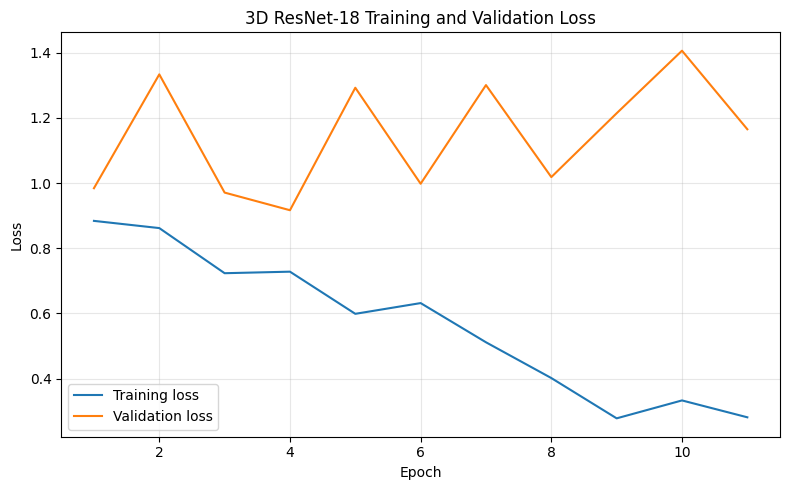

Saved: /kaggle/working/results_run2/training_validation_loss.png


In [16]:
# ============================================================
# CELL 17 — TRAINING CURVES
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["epoch"], history_df["train_loss"], label="Training loss")
ax.plot(history_df["epoch"], history_df["val_loss"], label="Validation loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("3D ResNet-18 Training and Validation Loss")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

loss_plot_path = RESULTS_DIR / "training_validation_loss.png"
plt.savefig(loss_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", loss_plot_path)

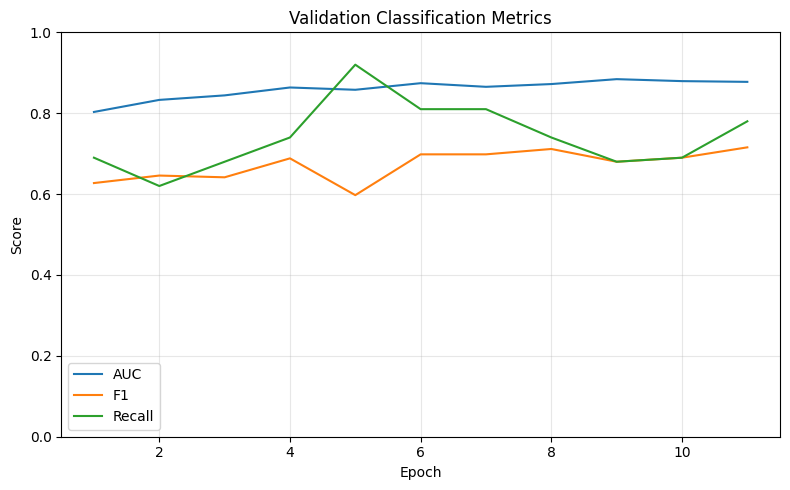

Saved: /kaggle/working/results_run2/validation_metrics.png


In [17]:
# ============================================================
# CELL 18 — VALIDATION METRIC CURVES
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(history_df["epoch"], history_df["val_auc"], label="AUC")
ax.plot(history_df["epoch"], history_df["val_f1"], label="F1")
ax.plot(history_df["epoch"], history_df["val_recall"], label="Recall")
ax.set_xlabel("Epoch")
ax.set_ylabel("Score")
ax.set_title("Validation Classification Metrics")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

metric_plot_path = RESULTS_DIR / "validation_metrics.png"
plt.savefig(metric_plot_path, dpi=150, bbox_inches="tight")
plt.show()
print("Saved:", metric_plot_path)

In [18]:
# ============================================================
# CELL 19 — LOAD BEST VALIDATION CHECKPOINT
# ============================================================

if not BEST_CHECKPOINT.exists():
    raise FileNotFoundError(
        f"Best checkpoint not found:\n{BEST_CHECKPOINT}"
    )

best_checkpoint = torch.load(
    BEST_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False,
)

model.load_state_dict(
    best_checkpoint["model_state"]
)

model.eval()

print("=" * 70)
print("BEST MODEL LOADED")
print("=" * 70)

print(
    "Best epoch:",
    best_checkpoint["epoch"]
)

print(
    "Best validation loss:",
    best_checkpoint["best_val_loss"]
)

print(
    "Stored validation metrics:",
    best_checkpoint["val_metrics"]
)

BEST MODEL LOADED
Best epoch: 4
Best validation loss: 0.9166195351084881
Stored validation metrics: {'accuracy': 0.8017751479289941, 'precision': 0.6434782608695652, 'recall': 0.74, 'specificity': np.float64(0.8277310924369747), 'f1': 0.6883720930232559, 'auc': np.float64(0.8636134453781512)}


In [19]:
# ============================================================
# CELL 20 — FINAL VALIDATION EVALUATION
# ============================================================

(val_loss, val_metrics, val_labels, val_probabilities,
 val_study_ids, val_eval_time) = evaluate(model, val_loader, criterion, DEVICE)

print("=" * 70)
print("BEST MODEL — VALIDATION RESULTS")
print("=" * 70)
print(f"Validation loss : {val_loss:.4f}")
print(f"Accuracy        : {val_metrics['accuracy']:.4f}")
print(f"Precision       : {val_metrics['precision']:.4f}")
print(f"Recall          : {val_metrics['recall']:.4f}")
print(f"Specificity     : {val_metrics['specificity']:.4f}")
print(f"F1              : {val_metrics['f1']:.4f}")
print(f"ROC-AUC         : {val_metrics['auc']:.4f}")

BEST MODEL — VALIDATION RESULTS
Validation loss : 0.9166
Accuracy        : 0.8018
Precision       : 0.6435
Recall          : 0.7400
Specificity     : 0.8277
F1              : 0.6884
ROC-AUC         : 0.8636


In [20]:
# ============================================================
# CELL 21 — FINAL TEST EVALUATION
# ============================================================

if test_loader is None:
    print("=" * 70)
    print("NO TEST SPLIT AVAILABLE")
    print("=" * 70)
    print(
        "The split file does not contain an independent test split. "
        "Do not describe the validation set as a test set."
    )
else:
    (test_loss, test_metrics, test_labels, test_probabilities,
     test_study_ids, test_eval_time) = evaluate(model, test_loader, criterion, DEVICE)

    print("=" * 70)
    print("FINAL TEST RESULTS")
    print("=" * 70)
    print(f"Test loss       : {test_loss:.4f}")
    print(f"Accuracy        : {test_metrics['accuracy']:.4f}")
    print(f"Precision       : {test_metrics['precision']:.4f}")
    print(f"Recall          : {test_metrics['recall']:.4f}")
    print(f"Specificity     : {test_metrics['specificity']:.4f}")
    print(f"F1              : {test_metrics['f1']:.4f}")
    print(f"ROC-AUC         : {test_metrics['auc']:.4f}")

FINAL TEST RESULTS
Test loss       : 1.0268
Accuracy        : 0.8071
Precision       : 0.6863
Recall          : 0.6796
Specificity     : 0.8632
F1              : 0.6829
ROC-AUC         : 0.8556


In [21]:
# ============================================================
# CELL 22 — SAVE MODEL PREDICTIONS
# ============================================================

val_predictions_df = pd.DataFrame({
    "study_id": val_study_ids,
    "label": val_labels.astype(int),
    "probability": val_probabilities,
})
val_predictions_path = RESULTS_DIR / "validation_predictions.csv"
val_predictions_df.to_csv(val_predictions_path, index=False)
print("Validation predictions saved:", val_predictions_path)

if test_loader is not None:
    test_predictions_df = pd.DataFrame({
        "study_id": test_study_ids,
        "label": test_labels.astype(int),
        "probability": test_probabilities,
    })
    test_predictions_path = RESULTS_DIR / "test_predictions.csv"
    test_predictions_df.to_csv(test_predictions_path, index=False)
    print("Test predictions saved:", test_predictions_path)

Validation predictions saved: /kaggle/working/results_run2/validation_predictions.csv
Test predictions saved: /kaggle/working/results_run2/test_predictions.csv


In [22]:
# ============================================================
# CELL 23 — GPU RESOURCE SUMMARY
# ============================================================

if DEVICE.type == "cuda":
    peak_memory_gb = torch.cuda.max_memory_allocated() / 1e9
    reserved_memory_gb = torch.cuda.max_memory_reserved() / 1e9

    print("=" * 70)
    print("GPU RESOURCE SUMMARY")
    print("=" * 70)
    print(f"Peak allocated memory : {peak_memory_gb:.2f} GB")
    print(f"Peak reserved memory  : {reserved_memory_gb:.2f} GB")
    print(f"Total GPU memory      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

GPU RESOURCE SUMMARY
Peak allocated memory : 10.95 GB
Peak reserved memory  : 13.36 GB
Total GPU memory      : 15.64 GB


In [23]:
# ============================================================
# CELL 24 — FINAL EXPERIMENT RECORD
# ============================================================

experiment_record = {
    "seed": SEED,
    "architecture": "3D ResNet-18",
    "pretraining": "Kinetics-400",
    "input_shape": "(1, 128, 160, 192)",
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
    "train_cases": len(train_df),
    "validation_cases": len(val_df),
    "test_cases": len(test_df),
    "best_epoch": int(best_checkpoint["epoch"]),
    "best_validation_loss": float(best_checkpoint["best_val_loss"]),
}

experiment_record_df = pd.DataFrame([experiment_record])
record_path = RESULTS_DIR / "experiment_record.csv"
experiment_record_df.to_csv(record_path, index=False)

print("=" * 70)
print("EXPERIMENT RECORD")
print("=" * 70)
for key, value in experiment_record.items():
    print(f"{key}: {value}")
print("\nSaved:", record_path)

EXPERIMENT RECORD
seed: 42
architecture: 3D ResNet-18
pretraining: Kinetics-400
input_shape: (1, 128, 160, 192)
batch_size: 4
learning_rate: 5e-05
weight_decay: 1e-05
max_epochs: 40
early_stopping_patience: 7
train_cases: 1563
validation_cases: 338
test_cases: 337
best_epoch: 4
best_validation_loss: 0.9166195351084881

Saved: /kaggle/working/results_run2/experiment_record.csv


## Training conclusion

The final 3D PDAC classification model was trained using full preprocessed pancreas-centered CT volumes.

The final model checkpoint selected for downstream analysis is the checkpoint with the lowest validation loss. The validation set was used for model selection and learning-rate scheduling, while an available independent test set was kept separate from training and model selection.

The saved predictions and best checkpoint provide the inputs required for the subsequent:

1. classification performance analysis,
2. calibration analysis,
3. temperature scaling,
4. reliability diagrams,
5. 3D Grad-CAM generation, and
6. quantitative explanation evaluation against the expert PDAC tumor mask.

The model architecture and preprocessing remain fixed for the baseline experiment. Further experiments, such as comparison with a 2D baseline, should be conducted as separate controlled experiments rather than modifying this baseline retrospectively.